# RQ4 — Does feeding UMDA's distribution to the LLM produce better results than using LLM or UMDA alone?

**Groups**:
- `UMDA4GI` — UMDAAlgorithm, no LLM
- `UMDA+llama3.1:8b` / `UMDA+qwen2.5-coder:7b` — UMDAAlgorithm guided by LLM
- `LLM-llama3.1:8b` / `LLM-qwen2.5-coder:7b` — LLMAlgorithm (no EDA distribution)

**Models**: llama3.1:8b and qwen2.5-coder:7b. llama3.2:3b discarded (too small, replaced).  
**Primary metric**: `change_perc_validate` (median across folds, then median across budgets).  
**Sign convention**: negative = improvement (fewer CPU cycles). Lower is better.  
**Data**: Perf<Cycles>, 5-fold CV (fold 1–5), budgets {100, 250, 500, 750, 1000}.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

os.makedirs('plots', exist_ok=True)

CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)


# Only llama3.1:8b and qwen2.5-coder:7b; llama3.2:3b discarded (too small, replaced)
MODELS_KEEP = {'llama3.1:8b', 'qwen2.5-coder:7b'}

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(['UMDAAlgorithm', 'LLMAlgorithm'])) &
    (df_all['llm_model'].isna() | df_all['llm_model'].isin(MODELS_KEEP))
].copy()

for col in ['change_perc_validate', 'change_perc_train', 'max_evals']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['max_evals'] = df['max_evals'].astype(int)

def assign_group(row):
    alg, llm = row['algorithm'], row['llm_model']
    if alg == 'UMDAAlgorithm' and pd.isna(llm):                    return 'UMDA4GI'
    if alg == 'UMDAAlgorithm' and llm == 'llama3.1:8b':            return 'UMDA+llama3.1:8b'
    if alg == 'UMDAAlgorithm' and llm == 'qwen2.5-coder:7b':       return 'UMDA+qwen2.5-coder:7b'
    if alg == 'LLMAlgorithm'  and llm == 'llama3.1:8b':            return 'LLM-llama3.1:8b'
    if alg == 'LLMAlgorithm'  and llm == 'qwen2.5-coder:7b':       return 'LLM-qwen2.5-coder:7b'
    return None

df['group'] = df.apply(assign_group, axis=1)
df = df[df['group'].notna()]
df['overfit'] = df['change_perc_validate'] - df['change_perc_train']

GROUP_ORDER = [
    'UMDA4GI',
    'UMDA+llama3.1:8b',
    'UMDA+qwen2.5-coder:7b',
    'LLM-llama3.1:8b',
    'LLM-qwen2.5-coder:7b',
]

software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j': 'Sat4J',
    'weka': 'Weka',
    'pngOptim': 'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']

FIXED_COLORS = {
    'UMDA4GI':                 cm.tab10(3),
    'UMDA+llama3.1:8b':        cm.tab10(4),
    'UMDA+qwen2.5-coder:7b':   cm.tab10(5),
    'LLM-llama3.1:8b':         cm.tab10(6),
    'LLM-qwen2.5-coder:7b':    cm.tab10(7),
}
color_map = {g: FIXED_COLORS[g] for g in GROUP_ORDER}
ls_map    = dict(zip(GROUP_ORDER, ['-', '--', ':', '-.', (0,(3,1,1,1))]))
mk_map    = dict(zip(GROUP_ORDER, ['o', 's', '^', 'D', 'v']))

print(f'Total rows: {len(df)}')
print(df.groupby('group').size().reindex(GROUP_ORDER).to_string())

Total rows: 500
group
UMDA4GI                  100
UMDA+llama3.1:8b         100
UMDA+qwen2.5-coder:7b    100
LLM-llama3.1:8b          100
LLM-qwen2.5-coder:7b     100


In [2]:
group_cols = ['software', 'group', 'max_evals']

agg = (
    df.groupby(group_cols, as_index=False)
      .agg(
          change_perc_validate=('change_perc_validate', 'median'),
          change_perc_train   =('change_perc_train',    'median'),
          overfit             =('overfit',              'median'),
          cpv_std             =('change_perc_validate', 'std'),
          n_folds             =('fold',                 'count'),
      )
)
agg['group'] = pd.Categorical(agg['group'], categories=GROUP_ORDER, ordered=True)
agg = agg.sort_values(['software', 'group', 'max_evals'])

incomplete = agg[agg['n_folds'] < 5]
if not incomplete.empty:
    print('WARNING — cells with < 5 folds:')
    print(incomplete[['software','group','max_evals','n_folds','change_perc_validate']].to_string(index=False))
print(f'\nAggregated rows: {len(agg)}')


Aggregated rows: 100


## 1. change_perc_validate vs max_evals (per software)
Median across folds per (software, group, budget). Y-axis inverted: lower = more improvement.

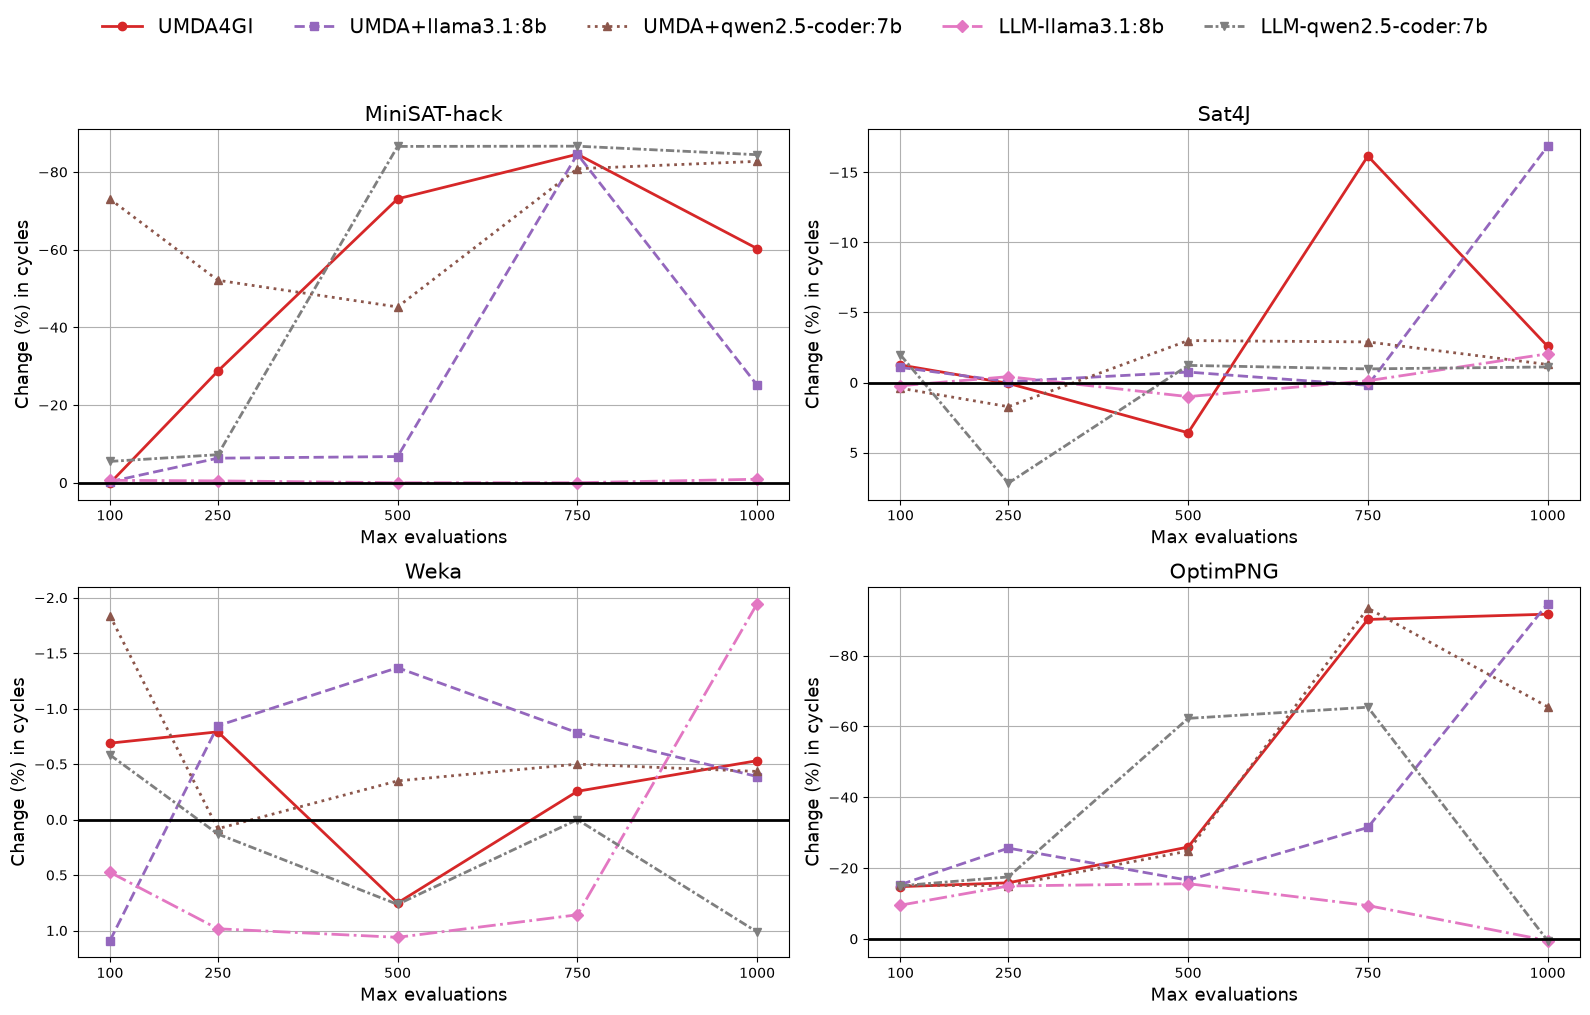

In [3]:
softwares = [sw for sw in desired_order if sw in agg['software'].values]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sw in zip(axes, softwares):
    sw_data = agg[agg['software'] == sw]
    for g in GROUP_ORDER:
        gd = sw_data[sw_data['group'] == g].sort_values('max_evals')
        if gd.empty: continue
        ax.plot(gd['max_evals'], gd['change_perc_validate'],
                label=g, color=color_map[g],
                linestyle=ls_map[g], marker=mk_map[g], linewidth=2, markersize=6)
    ax.set_title(software_display_map.get(sw, sw), fontsize=15)
    ax.set_xlabel('Max evaluations', fontsize=13)
    ax.set_ylabel('Change (%) in cycles', fontsize=13)
    ax.invert_yaxis()
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)): axes[i].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(GROUP_ORDER), fontsize='x-large', frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plots/RQ4_validate_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

## 2. Overfitting — (validate − train) vs max_evals (per software)

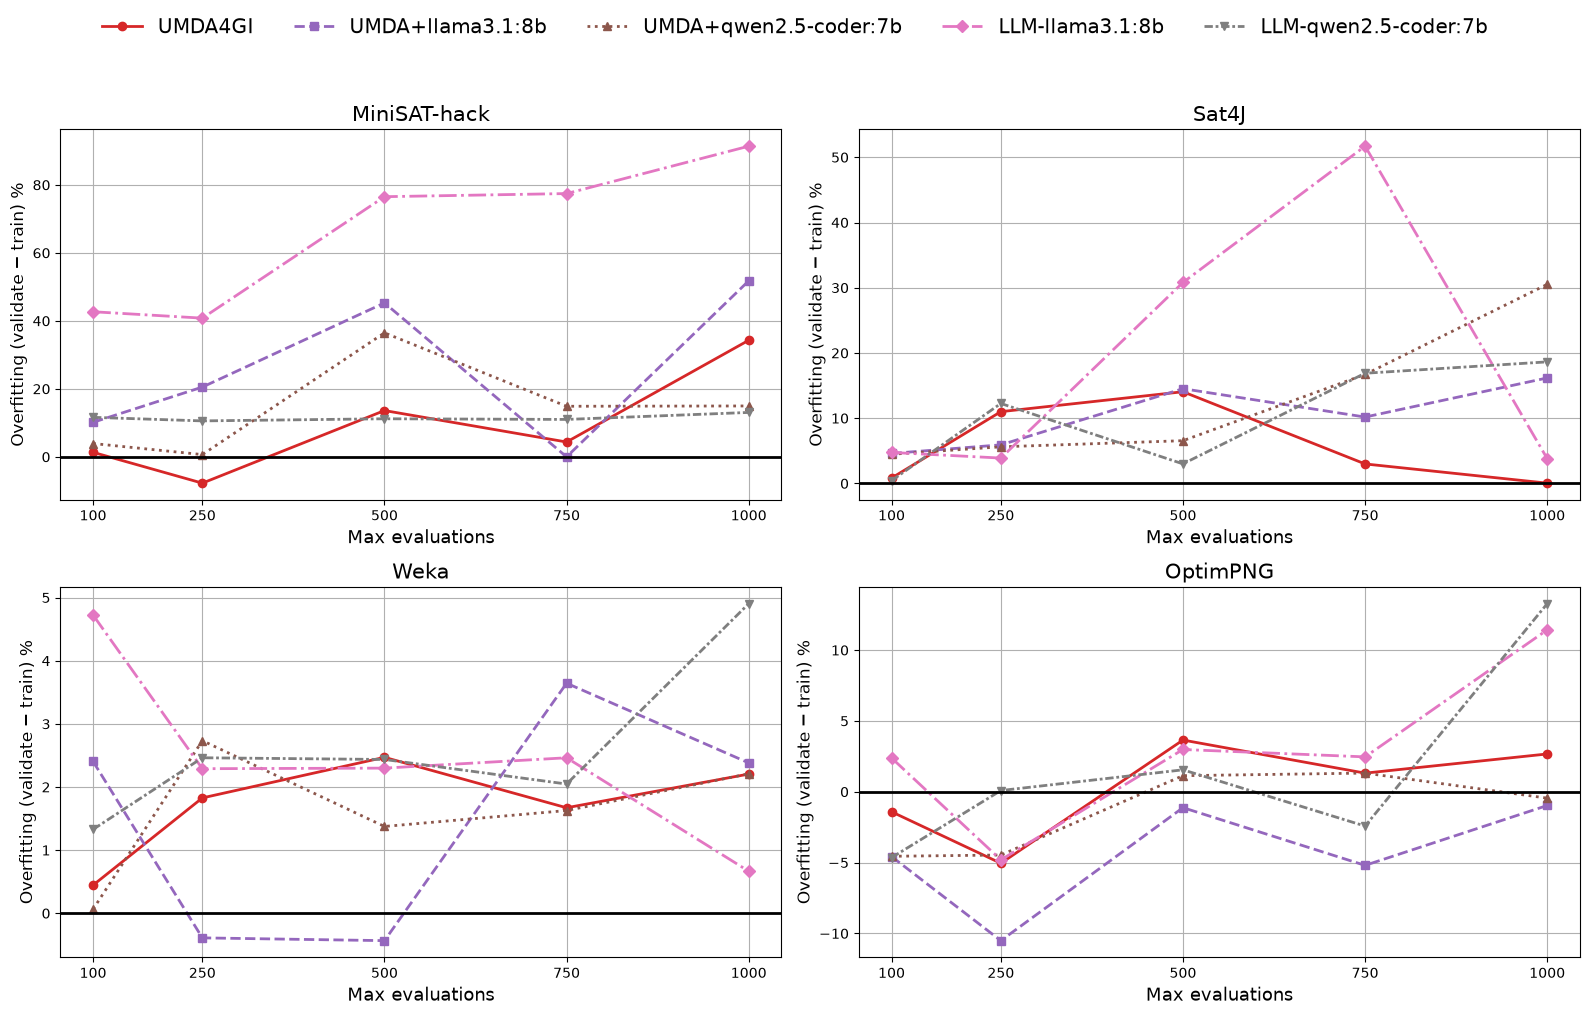

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sw in zip(axes, softwares):
    sw_data = agg[agg['software'] == sw]
    for g in GROUP_ORDER:
        gd = sw_data[sw_data['group'] == g].sort_values('max_evals')
        if gd.empty: continue
        ax.plot(gd['max_evals'], gd['overfit'],
                label=g, color=color_map[g],
                linestyle=ls_map[g], marker=mk_map[g], linewidth=2, markersize=6)
    ax.set_title(software_display_map.get(sw, sw), fontsize=15)
    ax.set_xlabel('Max evaluations', fontsize=13)
    ax.set_ylabel('Overfitting (validate − train) %', fontsize=12)
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)): axes[i].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(GROUP_ORDER), fontsize='x-large', frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plots/RQ4_overfitting_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

### 2.1 Ranking de algoritmos por overfitting (suma de rangos por software)

=== Rank per software (1 = least overfitting) — sum of ranks ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA4GI                         1.0       3.0    1.0   3.0   8.0
UMDA+llama3.1:8b                4.0       1.0    3.0   1.0   9.0
UMDA+qwen2.5-coder:7b           3.0       2.0    4.0   2.0  11.0
LLM-qwen2.5-coder:7b            2.0       4.0    2.0   5.0  13.0
LLM-llama3.1:8b                 5.0       5.0    5.0   4.0  19.0

=== Median overfitting (validate − train) % — lower = less overfitting ===
                       MiniSAT-hack  OptimPNG   Sat4J   Weka    Mean
group                                                               
UMDA4GI                       9.174     0.234   5.783  1.724   4.229
LLM-qwen2.5-coder:7b         11.493     1.568  10.242  2.636   6.485
UMDA+qwen2.5-coder:7b        14.182    -1.404  12.772  1.602   6.788
UMDA+llama3.1:8b             25.545    -4.475  10.276  1.52

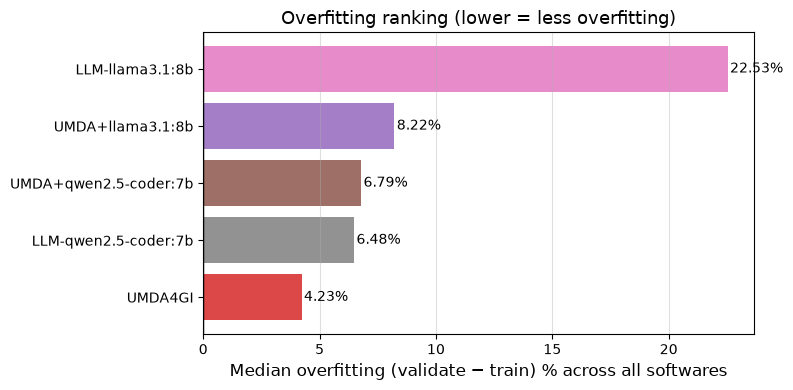

In [5]:
ov_per_sw = agg.groupby(['software', 'group'], as_index=False)['overfit'].mean()

ov_per_sw['rank'] = ov_per_sw.groupby('software')['overfit'].rank(method='min')

rank_ov = ov_per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
rank_ov.columns = [software_display_map.get(c, c) for c in rank_ov.columns]
rank_ov['Sum'] = rank_ov.sum(axis=1)
rank_ov = rank_ov.sort_values('Sum')
print('=== Rank per software (1 = least overfitting) — sum of ranks ===')
print(rank_ov.to_string())
print()

vals_ov = ov_per_sw.pivot(index='group', columns='software', values='overfit').reindex(GROUP_ORDER)
vals_ov.columns = [software_display_map.get(c, c) for c in vals_ov.columns]
vals_ov['Mean'] = vals_ov.mean(axis=1)
vals_ov = vals_ov.sort_values('Mean')
print('=== Median overfitting (validate − train) % — lower = less overfitting ===')
print(vals_ov.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(8, 4))
groups_sorted = vals_ov.index.tolist()
means_ov = vals_ov['Mean'].values
bars = ax.barh(groups_sorted, means_ov,
               color=[color_map[g] for g in groups_sorted], alpha=0.85)
ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('Median overfitting (validate − train) % across all softwares', fontsize=12)
ax.set_title('Overfitting ranking (lower = less overfitting)', fontsize=13)
for bar, val in zip(bars, means_ov):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='left', fontsize=10)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/RQ4_overfit_ranking.svg', format='svg', bbox_inches='tight')
plt.show()

## 3. Ranking de algoritmos por porcentaje de mejora en validación

=== Median change_perc_validate (%) — lower = better improvement ===
                       MiniSAT-hack  OptimPNG  Sat4J   Weka    Mean
group                                                              
UMDA+qwen2.5-coder:7b       -66.794   -42.776 -1.010 -0.608 -27.797
UMDA4GI                     -49.310   -47.686 -3.270 -0.303 -25.142
LLM-qwen2.5-coder:7b        -54.073   -31.936  0.381  0.265 -21.341
UMDA+llama3.1:8b            -24.599   -36.732 -3.712 -0.459 -16.376
LLM-llama3.1:8b              -0.397    -9.797 -0.272  0.286  -2.545

=== Rank per software (1 = most improvement) — sum of ranks ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA+qwen2.5-coder:7b           1.0       2.0    3.0   1.0   7.0
UMDA4GI                         3.0       1.0    2.0   3.0   9.0
UMDA+llama3.1:8b                4.0       3.0    1.0   2.0  10.0
LLM-qwen2.5-coder:7b            2.0       4.0    5.0   4.0  15.0


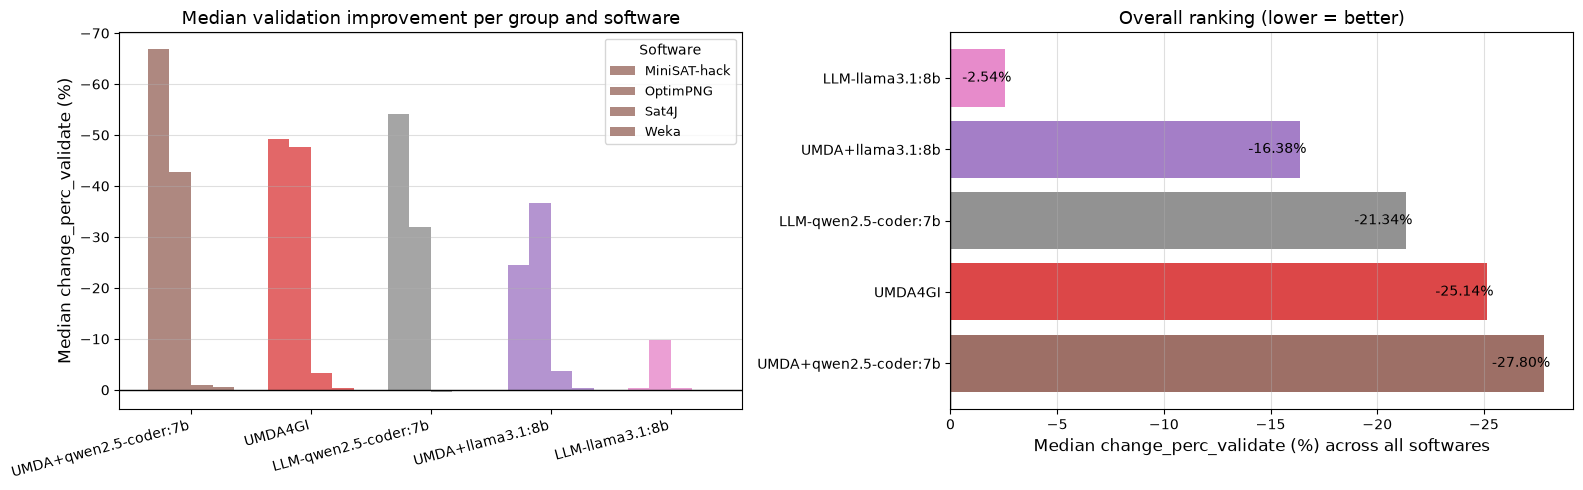

In [6]:
# --- Median-per-budget, then mean across budgets per (group, software) ---
avg_per_sw = agg.groupby(['software', 'group'], as_index=False)['change_perc_validate'].mean()

vals_sw = avg_per_sw.pivot(index='group', columns='software', values='change_perc_validate').reindex(GROUP_ORDER)
vals_sw.columns = [software_display_map.get(c, c) for c in vals_sw.columns]
vals_sw['Mean'] = vals_sw.mean(axis=1)
vals_sw = vals_sw.sort_values('Mean')

print('=== Median change_perc_validate (%) — lower = better improvement ===')
print(vals_sw.round(3).to_string())
print()

# --- Rank within each software (1 = best) ---
avg_per_sw['rank'] = avg_per_sw.groupby('software')['change_perc_validate'].rank(method='min')
rank_sw = avg_per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
rank_sw.columns = [software_display_map.get(c, c) for c in rank_sw.columns]
rank_sw['Sum'] = rank_sw.sum(axis=1)
rank_sw = rank_sw.sort_values('Sum')

print('=== Rank per software (1 = most improvement) — sum of ranks ===')
print(rank_sw.to_string())
print()

# --- Overall ranking bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x = np.arange(len(vals_sw.index))
width = 0.18
sw_cols = [c for c in vals_sw.columns if c != 'Mean']
for i, sw_col in enumerate(sw_cols):
    ax.bar(x + i * width, vals_sw[sw_col], width,
           label=sw_col,
           color=[color_map[g] for g in vals_sw.index], alpha=0.7)
ax.set_xticks(x + width * (len(sw_cols) - 1) / 2)
ax.set_xticklabels(vals_sw.index, rotation=15, ha='right')
ax.axhline(0, color='k', linewidth=1)
ax.set_ylabel('Median change_perc_validate (%)', fontsize=12)
ax.set_title('Median validation improvement per group and software', fontsize=13)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.4)
ax.legend(title='Software', fontsize=9)

ax2 = axes[1]
groups_sorted = vals_sw.index.tolist()
means = vals_sw['Mean'].values
bars = ax2.barh(groups_sorted, means,
                color=[color_map[g] for g in groups_sorted], alpha=0.85)
ax2.axvline(0, color='k', linewidth=1)
ax2.set_xlabel('Median change_perc_validate (%) across all softwares', fontsize=12)
ax2.set_title('Overall ranking (lower = better)', fontsize=13)
ax2.invert_xaxis()
for bar, val in zip(bars, means):
    ax2.text(val - 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', ha='right', fontsize=10)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('plots/RQ4_ranking.svg', format='svg', bbox_inches='tight')
plt.show()

### 3.2 Normalized relative improvement

For each software, each group's mean is expressed as a fraction of the best group on that software  
(best = most negative = 1.0). Groups that degrade get negative scores. Average across softwares gives equal weight to each software regardless of absolute improvement magnitude.

=== Normalized relative improvement (1.0 = best on that software) ===
Higher = better. Negative = degradation.
                       MiniSAT-hack  OptimPNG  Sat4J   Weka   Mean
group                                                             
UMDA+qwen2.5-coder:7b         1.000     0.897  0.272  1.000  0.792
UMDA4GI                       0.738     1.000  0.881  0.499  0.779
UMDA+llama3.1:8b              0.368     0.770  1.000  0.755  0.724
LLM-qwen2.5-coder:7b          0.810     0.670 -0.103 -0.436  0.235
LLM-llama3.1:8b               0.006     0.205  0.073 -0.471 -0.047



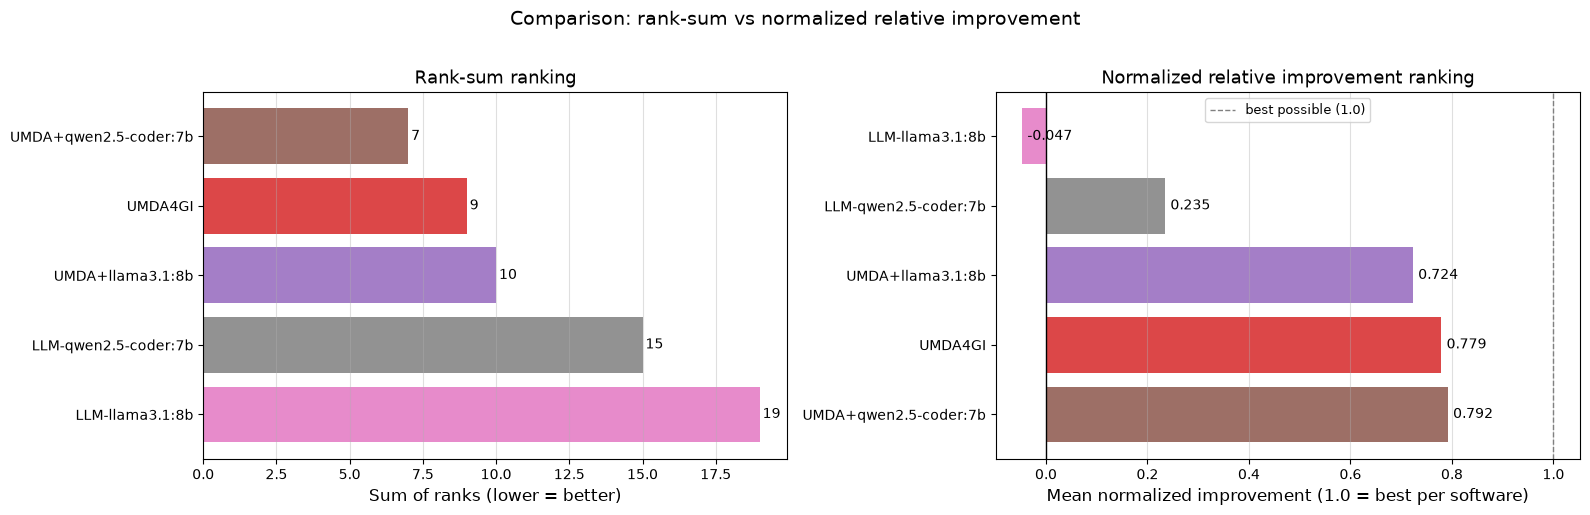

In [7]:
# Normalized relative improvement: score = group_mean / best_mean per software
# best_mean = most negative value (max improvement)
best_per_sw = avg_per_sw.groupby('software')['change_perc_validate'].min()  # min = most negative

norm = avg_per_sw.copy()
norm['norm_score'] = norm.apply(
    lambda r: r['change_perc_validate'] / best_per_sw[r['software']]
    if best_per_sw[r['software']] != 0 else 0.0,
    axis=1
)

vals_norm = norm.pivot(index='group', columns='software', values='norm_score').reindex(GROUP_ORDER)
vals_norm.columns = [software_display_map.get(c, c) for c in vals_norm.columns]
vals_norm['Mean'] = vals_norm.mean(axis=1)
vals_norm = vals_norm.sort_values('Mean', ascending=False)  # higher = better (1.0 = best on that sw)

print('=== Normalized relative improvement (1.0 = best on that software) ===')
print('Higher = better. Negative = degradation.')
print(vals_norm.round(3).to_string())
print()

# Side-by-side: rank-sum vs normalized
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: rank-sum (already computed above)
ax1 = axes[0]
rank_sorted = rank_sw.sort_values('Sum')
ax1.barh(rank_sorted.index[::-1], rank_sorted['Sum'][::-1],
         color=[color_map[g] for g in rank_sorted.index[::-1]], alpha=0.85)
ax1.set_xlabel('Sum of ranks (lower = better)', fontsize=12)
ax1.set_title('Rank-sum ranking', fontsize=13)
for i, (g, val) in enumerate(zip(rank_sorted.index[::-1], rank_sorted['Sum'][::-1])):
    ax1.text(val + 0.1, i, f'{int(val)}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.4)

# Right: normalized mean
ax2 = axes[1]
groups_norm = vals_norm.index.tolist()
means_norm = vals_norm['Mean'].values
bars = ax2.barh(groups_norm, means_norm,
                color=[color_map[g] for g in groups_norm], alpha=0.85)
ax2.axvline(0, color='k', linewidth=1)
ax2.axvline(1, color='gray', linewidth=1, linestyle='--', label='best possible (1.0)')
ax2.set_xlabel('Mean normalized improvement (1.0 = best per software)', fontsize=12)
ax2.set_title('Normalized relative improvement ranking', fontsize=13)
for bar, val in zip(bars, means_norm):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.4)

plt.suptitle('Comparison: rank-sum vs normalized relative improvement', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/RQ4_ranking_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

## RQ4 — Conclusions

> **Note (2026-08-13).** Computed with (a) `change_perc_train` recovered from the MAGPIE logs
> (see the `[FIX]` block in the setup cell) for 42 rows whose CSV value was lost when an
> exception killed the run after `hook_end`, and (b) the 37 Weka/OptimPNG runs that had been
> lost to a cluster-side warm-up failure, now re-run. Every group is complete at 100 runs.
> `RQ4b.ipynb` shows the effect of the `change_perc_train` correction in isolation.

### Direct answer

**Partially yes. Providing UMDA's distribution to the LLM improves results over using LLM alone, but UMDA4GI without LLM remains the best overall.**

Dataset: 500 rows (100 per group). Models: llama3.1:8b and qwen2.5-coder:7b (llama3.2:3b discarded — too small, replaced; qwen2.5:14b excluded, not part of this study). Aggregation: median across folds per budget, then mean across budgets per software (consistent with RQ1–RQ3).

### Per-software findings

| Software | Best group | Worst group | Notes |
|----------|------------|-------------|-------|
| MiniSAT-hack | UMDA+qwen2.5-coder:7b (−66.8%) | LLM-llama3.1:8b (−0.4%) | LLM-qwen (−54.1%) competitive; LLM-llama near zero |
| Sat4J | UMDA+llama3.1:8b (−3.7%) | LLM-qwen2.5-coder:7b (+0.4%) | LLM groups degrade or near zero |
| Weka | UMDA+qwen2.5-coder:7b (−0.61%) | LLM-llama3.1:8b (+0.29%) | Differences tiny; LLM-pure slightly degrades |
| OptimPNG | UMDA4GI (−47.7%) | LLM-llama3.1:8b (−9.8%) | Large improvements; UMDA variants far ahead |

### Global ranking — three metrics

| Position | Rank-sum (improvement) | Norm. relative | Rank-sum (overfitting) |
|----------|------------------------|----------------|------------------------|
| 1 | **UMDA+qwen2.5-coder:7b** (7) | **UMDA+qwen2.5-coder:7b** (0.792) | **UMDA4GI** (8) |
| 2 | **UMDA4GI** (9) | UMDA4GI (0.779) | UMDA+llama3.1:8b (9) |
| 3 | UMDA+llama3.1:8b (10) | UMDA+llama3.1:8b (0.724) | UMDA+qwen2.5-coder:7b (11) |
| 4 | LLM-qwen2.5-coder:7b (15) | LLM-qwen2.5-coder:7b (0.235) | LLM-qwen2.5-coder:7b (13) |
| 5 | LLM-llama3.1:8b (19) | LLM-llama3.1:8b (−0.047) | LLM-llama3.1:8b (19) |

*Rank-sum improvement: lower = better. Norm. relative: higher = better (1.0 = best per software). Rank-sum overfitting: lower = less overfitting.*

Mean overfitting across softwares: UMDA4GI (+4.23%) < LLM-qwen2.5-coder:7b (+6.49%) < UMDA+qwen2.5-coder:7b (+6.79%) < UMDA+llama3.1:8b (+8.22%) < LLM-llama3.1:8b (+22.53%).

### Interpretation

1. **UMDA distribution consistently helps LLM.** UMDA+qwen2.5-coder:7b (7) beats LLM-qwen2.5-coder:7b (15) by 8 rank positions; UMDA+llama3.1:8b (10) beats LLM-llama3.1:8b (19) by 9. Holds across all three metrics.

2. **UMDA+qwen2.5-coder:7b and UMDA4GI are nearly tied at the top** (rank-sum 7 vs 9, normalized 0.792 vs 0.779), but they separate on generalisation: UMDA4GI has the **smallest** generalisation gap of the five groups (+4.23% vs +6.79%), so the small improvement edge of UMDA+qwen is paid for in generalisation.

3. **LLM-pure strategies are the weakest.** LLM-llama3.1:8b ranks last on both improvement (19) and overfitting (19), with a mean gap of +22.53%. LLM-qwen2.5-coder:7b performs well on MiniSAT-hack but degrades Sat4J and Weka.

4. **Patch-finding is no longer a differentiator.** With the lost Weka runs re-run, every group finds an improving patch in 99–100% of runs. The earlier 8–15% failure rate attributed to LLM-pure search was an artefact of runs that never executed, not a property of the algorithms.

5. **By normalized score, all three UMDA variants dominate** (0.724–0.792 vs −0.047–0.235 for LLM-pure). The EDA component is the primary driver of GI performance regardless of LLM involvement.


## 4. Patch-finding rate — missing validations per group

=== Patch-finding rate (validate_log present vs missing) ===
A missing validate_log means the run produced no improving patch (patch_length=0).

                Group  Runs  Patch found  No patch  No patch %
              UMDA4GI   100          100         0         0.0
     UMDA+llama3.1:8b   100          100         0         0.0
UMDA+qwen2.5-coder:7b   100          100         0         0.0
      LLM-llama3.1:8b   100          100         0         0.0
 LLM-qwen2.5-coder:7b   100           99         1         1.0


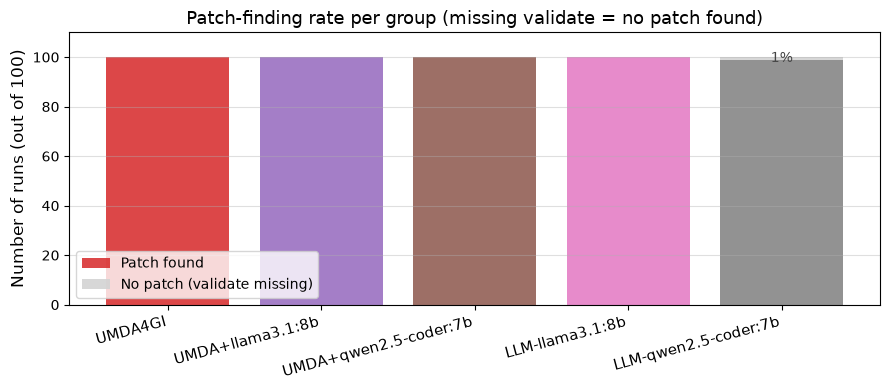


Key finding: every group finds an improving patch in 99-100% of runs.
The gap reported previously (8-15% for LLM-pure) was an artefact of Weka runs lost to a
cluster-side warm-up failure, since re-run; it was not a property of the algorithms.


In [8]:
missing = df.copy()
missing['missing_val'] = missing['validate_log'].isna() | (missing['validate_log'].astype(str).str.strip() == '')

tbl = missing.groupby(['algorithm', 'llm_model'], dropna=False).agg(
    total=('validate_log', 'size'),
    missing=('missing_val', 'sum'),
).reset_index()
tbl['found'] = tbl['total'] - tbl['missing']
tbl['pct_missing'] = (tbl['missing'] / tbl['total'] * 100).round(1)
tbl['llm_model'] = tbl['llm_model'].fillna('(none)')

# Map to display names consistent with GROUP_ORDER
def to_group(row):
    alg, llm = row['algorithm'], row['llm_model']
    if alg == 'UMDAAlgorithm'  and llm == '(none)':             return 'UMDA4GI'
    if alg == 'UMDAAlgorithm'  and llm == 'llama3.1:8b':        return 'UMDA+llama3.1:8b'
    if alg == 'UMDAAlgorithm'  and llm == 'qwen2.5-coder:7b':   return 'UMDA+qwen2.5-coder:7b'
    if alg == 'LLMAlgorithm'   and llm == 'llama3.1:8b':        return 'LLM-llama3.1:8b'
    if alg == 'LLMAlgorithm'   and llm == 'qwen2.5-coder:7b':   return 'LLM-qwen2.5-coder:7b'
    return None

tbl['group'] = tbl.apply(to_group, axis=1)
tbl = tbl[tbl['group'].notna()].copy()
tbl['group'] = pd.Categorical(tbl['group'], categories=GROUP_ORDER, ordered=True)
tbl = tbl.sort_values('group')[['group', 'total', 'found', 'missing', 'pct_missing']]

print('=== Patch-finding rate (validate_log present vs missing) ===')
print('A missing validate_log means the run produced no improving patch (patch_length=0).')
print()
print(tbl.rename(columns={
    'group': 'Group', 'total': 'Runs', 'found': 'Patch found',
    'missing': 'No patch', 'pct_missing': 'No patch %'
}).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
groups = tbl['group'].tolist()
x = np.arange(len(groups))
bars_found  = ax.bar(x, tbl['found'].values,   label='Patch found',  color=[color_map[g] for g in groups], alpha=0.85)
bars_missing = ax.bar(x, tbl['missing'].values, bottom=tbl['found'].values,
                      label='No patch (validate missing)', color='lightgray', alpha=0.9)
for bar, pct in zip(bars_missing, tbl['pct_missing'].values):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_y() + bar.get_height()/2,
                f'{pct:.0f}%', ha='center', va='center', fontsize=10, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('Number of runs (out of 100)', fontsize=12)
ax.set_title('Patch-finding rate per group (missing validate = no patch found)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/RQ4_patch_found_rate.svg', format='svg', bbox_inches='tight')
plt.show()

print()
print('Key finding: every group finds an improving patch in 99-100% of runs.')
print('The gap reported previously (8-15% for LLM-pure) was an artefact of Weka runs lost to a')
print('cluster-side warm-up failure, since re-run; it was not a property of the algorithms.')


### 4.1 Why is the validate missing? Root cause analysis (LLM-pure groups only)

In [9]:
# The single run without a validated patch, reported directly from results.csv.
missing = df[df['validate_log'].isna() | (df['validate_log'].astype(str).str.strip() == '')]
print('=== Runs with no improving patch ===')
if missing.empty:
    print('None: every run produced a validated patch.')
else:
    print(missing[['software', 'group', 'fold', 'max_evals', 'Vt', 'Vc',
                   'search_time_minutes']].to_string(index=False))
    print()
    print('This run exhausted its full evaluation budget without finding an improving')
    print('variant, i.e. it is a genuine search failure rather than a lost run.')


=== Runs with no improving patch ===
software                group  fold  max_evals    Vt    Vc  search_time_minutes
    weka LLM-qwen2.5-coder:7b     2        750 0.325 0.332           191.255417

This run exhausted its full evaluation budget without finding an improving
variant, i.e. it is a genuine search failure rather than a lost run.


---

## Appendix — LLM Prompt Structure

This appendix documents the exact prompt sent to the LLM in each algorithm variant, as implemented in `magpie/algos/umda_algorithm.py` (`_craft_population_prompt`) and `magpie/algos/llm_algorithm.py`.

### A.1 UMDA+LLM prompt (4 blocks)

**Block 1 — Task description + full source code**
```
In the context of Genetic Improvement of software, I want to create {pop_size} new Patches
for the following original software.

Each patch contains 1 or more edits in the MAGPIE framework format
(XmlNodeDeletion, XmlNodeReplacement, or XmlNodeInsertion).
Multiple edits in a patch are separated by "|".

The fitness goal is to reduce the execution time of the original software.

This is the original software:
{full source code of the target software}
```

**Block 2 — Best patches found so far (shared with LLM-pure)**
```
Here are the best patches found so far (lower fitness = faster execution):
1. XmlNodeDeletion<stmt>(('Solver.java.xml', 'stmt', 45))  (fitness: [74420209495])
2. XmlNodeReplacement<stmt>(('Solver.java.xml', 'stmt', 375), (...)) | ...  (fitness: [...])
...

You may draw inspiration from these examples, but do not simply copy them.
Be creative in combining, extending, or modifying the edits shown.
```

**Block 3 — UMDA distribution (UMDA+LLM only, absent in LLM-pure)**
```
Additionally, here is the probability distribution of individual edits
learned from past successful patches (higher probability = more frequently useful):
  XmlNodeDeletion<stmt>(('Solver.java.xml', 'stmt', 45)): 0.312
  XmlNodeReplacement<stmt>(('Solver.java.xml', 'stmt', 375), (...)): 0.187
  XmlNodeInsertion<stmt,block>((...), (...)): 0.143
  ...

Use this distribution as a guide, but feel free to combine edits creatively
or propose edits not listed in the distribution.
```

**Block 4 — Output format specification (shared with LLM-pure)**
```
Respect the required format, only reply with a numbered set of {pop_size} patch+explanation,
no further extra text. For instance:
Patch 1: XmlNodeDeletion<stmt>(('file.xml', 'stmt', 3))
Explanation 1: Removes an unnecessary statement to reduce execution time.
Patch 2: XmlNodeDeletion<stmt>(('file.xml', 'stmt', 5)) | XmlNodeInsertion<stmt,block>(('file.xml', '_inter_block', 2), ('file.xml', 'stmt', 1))
Explanation 2: Combines a deletion with an insertion to restructure a hot path.
```

### A.2 LLM-pure prompt (Blocks 1, 2, 4 only)

`LLMAlgorithm` sends the same prompt **without Block 3**. It has access to the source code and to the best patches found so far, but receives no information about which individual edits have been statistically useful across past generations.

### A.3 Key difference

Block 3 encodes the **marginal probability distribution** learned by UMDA over individual edits from all successful patches in previous generations. It gives the LLM a structured prior over which code locations and edit types have been empirically useful, narrowing the search space from the full AST to a ranked set of candidates. This is the mechanism by which UMDA+LLM combines evolutionary search with language model generation.